# 예측

In [ ]:
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "Malgun Gothic")
# 음수 표시
matplotlib.rc('axes', unicode_minus=False)

In [ ]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [ ]:
# 186 Page
# 데이터 구성:Series, DataFrame
import pandas as pd
import numpy as np
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 데이터 분할:train, test
from sklearn.model_selection import train_test_split

# 회귀분석
import statsmodels.formula.api as smf
# Decision Tree
from sklearn.tree import DecisionTreeRegressor
# Random Forest
from sklearn.ensemble import RandomForestRegressor
# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
# 평가 함수
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

### STEP ❶ 데이터 구성하기

In [ ]:
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\보험료.csv", encoding = "euc-kr")
df_raw.head()


# 단위를 나타내는 항목 제외
df_raw = df_raw.drop(['고객번호'], axis = 1)

# 범주형 변수의 Dummy 변수화
df_raw_dummy = pd.get_dummies(df_raw)
df_raw_dummy.head()


df_raw_dummy.isnull().sum()


# 목표변수, 설명변수 데이터 지정
df_raw_y = df_raw_dummy["보험료"]

# 설명변수(x)에는 '보험료'를 제외한 나머지 모든 컬럼을 지정
# (나머지 성별_남성, 가입유형_홈쇼핑 등 0과 1로 변한 데이터들이 다 )
df_raw_x = df_raw_dummy.drop("보험료", axis = 1, inplace = False)

로지스틱 회귀 (Logistic Regression)주로 분류(Classification) 문제에서 사용됩니다.   
특정 데이터가 특정 클래스에 속할 확률을 $0$에서 $1$ 사이의 값으로 예측합니다.  

선형 회귀 (Linear Regression)  
주로 회귀(Regression) 문제에서 사용됩니다. 독립 변수와 종속 변수 간의 선형 관계를 모델링하여 연속적인 수치를 예측합니다.

#### STEP ❷ 예측 모델 생성

In [ ]:

# train_test_split(X: 설명변수 데이터, Y: 목표변수 데이터, test_size = test 데이터 비율, random_state: random seed)
df_train, df_test = train_test_split(df_raw_dummy, test_size = 0.3, random_state = 1234)
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y
                                                                , test_size = 0.3, random_state = 1234)

In [ ]:
# 회귀 모델 (목표변수: 보험료, 설명변수는 나누어진 df_train 사용)
# 주의: 컬럼명에 공백이나 특수문자가 있다면 Q("컬럼명") 형태를 써야 할 수도 있습니다.
# 여기서는 예시로 주요 변수 몇 개만 넣거나 전체를 포함해야 합니다.
lr_model = smf.ols(formula = "보험료 ~ 나이 + BMI + 자녀수 + 흡연여부 + 성별_남성 + 성별_여성", data = df_train)
lr_result = lr_model.fit()

# Decision Tree
dt_model = DecisionTreeRegressor(random_state=1234, min_samples_leaf = 8, min_samples_split = 20, max_depth = 4 )
dt_model.fit(df_train_x, df_train_y)

# Random Forest
rf_model = RandomForestRegressor(random_state=1234, n_estimators = 100, min_samples_leaf = 6,
                                 min_samples_split = 14, max_depth = 4)
rf_model.fit(df_train_x, df_train_y)

# Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=1234, n_estimators = 30, min_samples_leaf = 11, 
                                     min_samples_split = 22, max_depth = 4, learning_rate = 0.1)
gb_model.fit(df_train_x, df_train_y)

GradientBoostingRegressor(max_depth=4, min_samples_leaf=11,
                          min_samples_split=22, n_estimators=30,
                          random_state=1234)

### STEP ❸ 예측 및 평가

In [ ]:
# 모델 리스트, 그래프를 그리기 생성 목적
models = ["회귀분석", "의사결정나무", "랜덤 포레스트", "그래디언트 부스팅"]
# 평가 리스트 초기화
mse, rmse, mae, mape = [],[],[],[]

# 회귀분석예측
lr_y_pred = lr_result.predict(df_test)

# 평가
mse.append(mean_squared_error(df_test['보험료'], lr_y_pred))       # 초기화 해둔 ㄹ리스트에 추가
# rmse.append(mean_squared_error(df_test_y, lr_y_pred, squared=False))
rmse.append(np.sqrt(mean_squared_error(df_test_y, lr_y_pred)))
mae.append(mean_absolute_error(df_test['보험료'], lr_y_pred))
mape.append(mean_absolute_percentage_error(df_test['보험료'], lr_y_pred))

# 의사결정나무예측
dt_y_pred = dt_model.predict(df_test_x)

# 평가
mse.append(mean_squared_error(df_test_y, dt_y_pred))
# rmse.append(mean_squared_error(df_test_y, dt_y_pred, squared=False))
rmse.append(np.sqrt(mean_squared_error(df_test_y, dt_y_pred)))
mae.append(mean_absolute_error(df_test_y, dt_y_pred))
mape.append(mean_absolute_percentage_error(df_test_y, dt_y_pred))

# 랜덤포레스트예측
rf_y_pred = rf_model.predict(df_test_x)

# 평가
mse.append(mean_squared_error(df_test_y, rf_y_pred))
# rmse.append(mean_squared_error(df_test_y, rf_y_pred, squared=False))
rmse.append(np.sqrt(mean_squared_error(df_test_y, rf_y_pred)))
mae.append(mean_absolute_error(df_test_y, rf_y_pred))
mape.append(mean_absolute_percentage_error(df_test_y, rf_y_pred))

# 그래디언트부스팀예측
gb_y_pred = gb_model.predict(df_test_x)

# 평가
mse.append(mean_squared_error(df_test_y, gb_y_pred))
# rmse.append(mean_squared_error(df_test_y, gb_y_pred, squared=False))
rmse.append(np.sqrt(mean_squared_error(df_test_y, gb_y_pred)))
mae.append(mean_absolute_error(df_test_y, gb_y_pred))
mape.append(mean_absolute_percentage_error(df_test_y, gb_y_pred))

### STEP ❹ 시각화

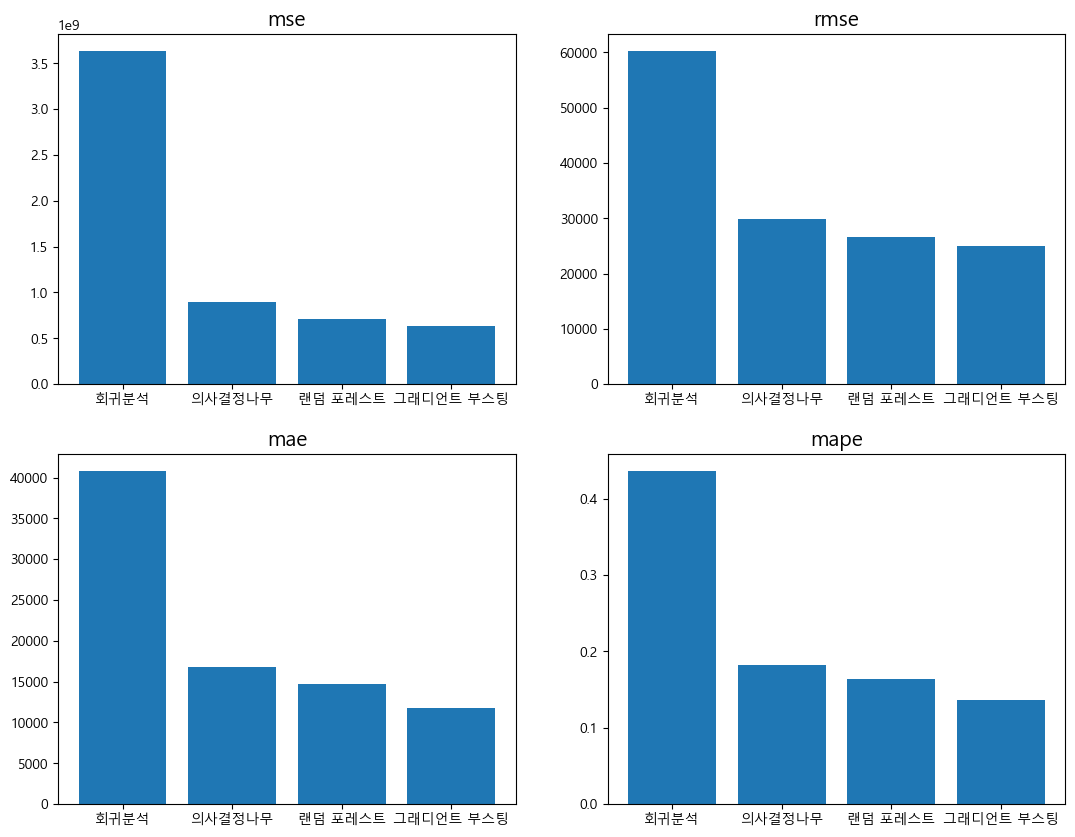

In [ ]:
fig, ax = plt.subplots(2,2, figsize = (13,10))
ax[0, 0].bar(models, mse)
ax[0, 0].set_title("mse").set_fontsize(15)

ax[0, 1].bar(models, rmse)
ax[0, 1].set_title("rmse").set_fontsize(15)

ax[1, 0].bar(models, mae)
ax[1, 0].set_title("mae").set_fontsize(15)

ax[1, 1].bar(models, mape)
ax[1, 1].set_title("mape").set_fontsize(15)

### 결론

제일 큰 게 안좋은 거임  
제일 작은게 좋은거임

최적 모델: 그래디언트 부스팅

모든 지표(MSE, RMSE, MAE, MAPE)에서 오차가 가장 적어 예측 성능이 가장 우수합니다.

모델별 성능 흐름

회귀분석(낮음) → 의사결정나무 → 랜덤 포레스트 → 그래디언트 부스팅(높음) 순으로 성능이 좋아집니다.

단순 선형 모델보다 복잡한 앙상블 모델이 보험료 예측에 더 적합함을 보여줍니다.

수치적 의미 (MAPE 기준)

최적 모델의 오차율은 약 13~15% 수준입니다.

실제 보험료와 비교했을 때 상당히 실용적인 수준의 예측력을 확보했습니다.

![image.png](attachment:image.png)

설명 변수(X) : 나머지   
목표 변수(Y) : SPECIES

In [ ]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 행렬 연산
import numpy as np
# 데이터 시각화
import matplotlib ;  import matplotlib.pyplot as plt
# 데이터 시각화:추세, 산점도 행렬 
import seaborn as sns
# Scale 변환:평균,표준편차 기준
from sklearn.preprocessing import StandardScaler

# 주성분 분석
from sklearn.decomposition import PCA
# 회귀분석
import statsmodels.api as sm
# 그래프 표시
%matplotlib inline

In [ ]:
# 맑은 고딕 적용
matplotlib.rc('font', family = 'Malgun Gothic')
# 음수 표시
matplotlib.rc('axes', unicode_minus = False)

### STEP ❶ : 데이터 구성하기

In [ ]:
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\IRIS.csv")
df_raw.head()

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH,SPECIES
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# 데이터 분리(Y, Xs) -> 설명변수를 이용한 주성분 분석
df_raw_x = df_raw.drop("SPECIES",axis=1)
df_raw_y = df_raw["SPECIES"]
df_raw_y.head()

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: SPECIES, dtype: object

### PCA의 목적은 여러 개의 변수를 중요한 몇 개의 축으로 합치는 것입니다.

설명변수(X): 꽃잎 길이, 너비 등 (축을 만드는 재료)

정답(Y): 품종(Species) (재료가 아닌 결과물)

SPECIES 만 따로 분리를 합시다.

In [ ]:
df_raw_x.head()

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### STEP ❷ 선형관계 확인: 산점도 및 상관계수

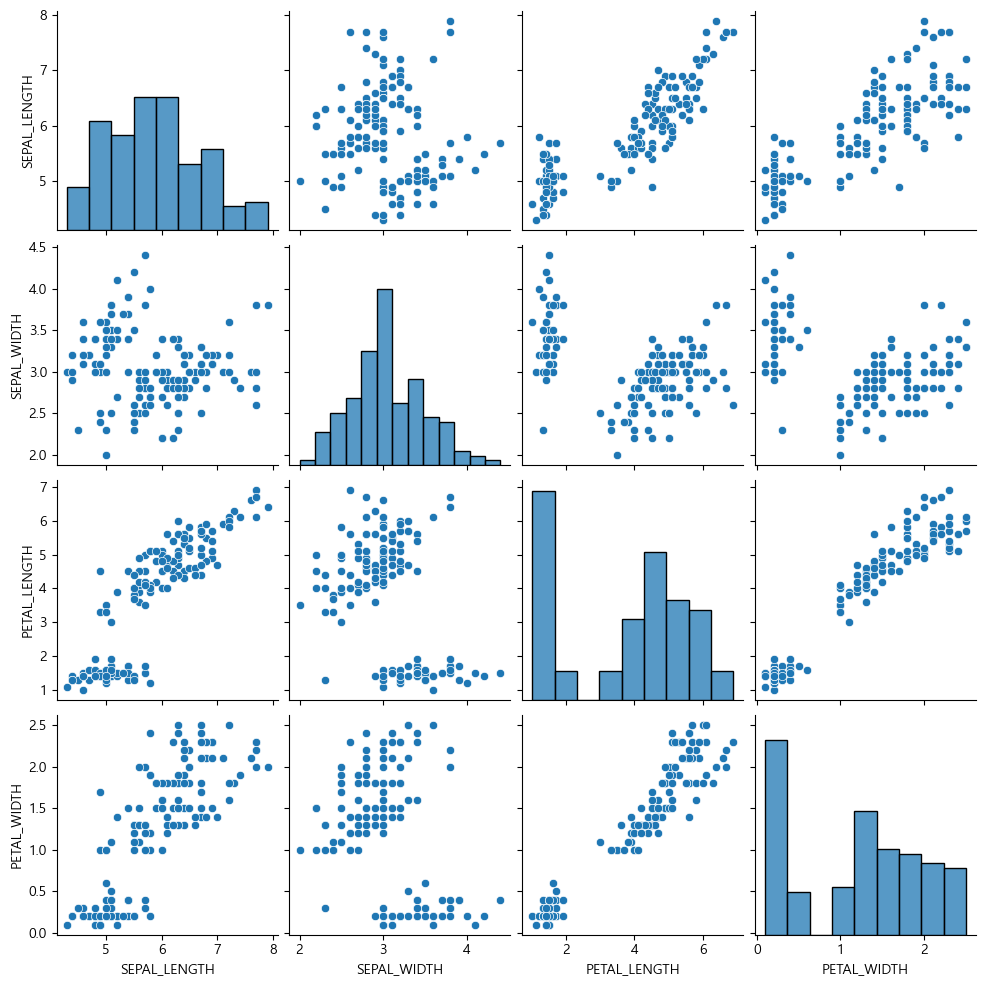

In [ ]:
# 산점도 행렬
sns.pairplot(df_raw_x)

강한 선형 관계: 특히 PETAL_LENGTH(꽃잎 길이)와 PETAL_WIDTH(꽃잎 너비) 사이의 산점도를 보면, 점들이 거의 직선에 가깝게 모여 있습니다. 이는 두 변수가 거의 같은 정보를 담고 있다는 뜻입니다.

정보의 중복: 이렇게 변수 간 상관관계가 높으면 데이터에 중복된 정보가 많다는 의미입니다.

### 상관계수

In [ ]:
# Pearson 상관계수: pearson, kendall, spearman
df_raw_x.corr().round(3)

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
SEPAL_LENGTH,1.000,-0.118,0.872,0.818
SEPAL_WIDTH,-0.118,1.000,-0.428,-0.366
PETAL_LENGTH,0.872,-0.428,1.000,0.963
PETAL_WIDTH,0.818,-0.366,0.963,1.000


(PETAL_LENGTH와 PETAL_WIDTH) : 0.963  
-> PCA로 겹치는 정보를 합쳐서 차원 축소 하자!

### STEP ❸ 데이터 확인 및 Scaling

In [ ]:
# 요약 통계량 -> Scale 변환 필요 확인
df_raw_x.describe().round(3)

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


스케일이 필요한지? 필요하지 않은지? 평균 비교하자  
-- > 스케일링(Scale 변환)이 반드시 필요하다


1. 평균(mean)의 차이  
SEPAL_LENGTH: 약 5.84

PETAL_WIDTH: 약 1.19

두 변수의 평균값 자체가 약 5배 정도 차이가 납니다. PCA는 숫자가 큰 변수를 "정보량이 더 많다"고 착각하기 때문에, 숫자가 큰 SEPAL_LENGTH에 휘둘릴 위험이 있습니다.

2. 표준편차(std)의 차이 (가장 중요한 이유)  
PCA는 분산(데이터가 퍼진 정도)을 극대화하는 축을 찾습니다.

SEPAL_WIDTH의 std: 0.436 (작게 퍼져 있음)

PETAL_LENGTH의 std: 1.765 (넓게 퍼져 있음)

PETAL_LENGTH의 표준편차가 4배 이상 큽니다. 스케일링을 안 하면 PCA는 "오, PETAL_LENGTH가 제일 넓게 퍼져 있네? 이게 제일 중요한 정보구나!"라고 판단하고 이 변수 위주로 축을 만들어 버립니다.

### 스케일링 

In [ ]:
# 변수 이름 저장
x_cols = df_raw_x.columns

# Scale 변환:ndarray 형식
scaler = StandardScaler()
nd_scaled = scaler.fit_transform(df_raw_x)

# 변환된 데이터 및 형태 확인
print("Scaled Data :\n {}".format(nd_scaled[:5].round(3)))
print("Shape :\n {}".format(nd_scaled.shape))

Scaled Data :
 [[-0.901  1.019 -1.34  -1.315]
 [-1.143 -0.132 -1.34  -1.315]
 [-1.385  0.328 -1.397 -1.315]
 [-1.507  0.098 -1.283 -1.315]
 [-1.022  1.249 -1.34  -1.315]]
Shape :
 (150, 4)


1. 데이터 표준화 실행 (StandardScaler)  
"모든 변수의 체급을 통일하다."  
변수마다 제각각이었던 측정 단위를 무시하고, 공평하게 비교할 수 있도록 평균 0, 표준편차 1인 표준정규분포 형태로 변환한 단계입니다.

In [ ]:
# DataFrame으로 저장
df_scaled = pd.DataFrame(nd_scaled, columns=x_cols ) 
df_scaled.head().round(3)

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
0,-0.901,1.019,-1.340,-1.315
1,-1.143,-0.132,-1.340,-1.315
2,-1.385,0.328,-1.397,-1.315
3,-1.507,0.098,-1.283,-1.315
4,-1.022,1.249,-1.340,-1.315


In [ ]:
# Scale 변환 데이터 요약 통계량
df_scaled.describe().round(3)

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
count,150.000,150.000,150.000,150.000
mean,-0.000,-0.000,-0.000,-0.000
std,1.003,1.003,1.003,1.003
min,-1.870,-2.434,-1.568,-1.447
25%,-0.901,-0.592,-1.227,-1.184
50%,-0.053,-0.132,0.336,0.133
75%,0.675,0.559,0.763,0.791
max,2.492,3.091,1.786,1.712


2. 스케일링 결과 확인 (describe)   
"모든 변수가 동일한 출발선에 섰음을 확인하다."  
표를 보면 모든 변수의 평균(mean)이 **-0.000(0에 수렴)**이고 표준편차(std)가 **1.003(1에 수렴)**으로 바뀐 것을 볼 수 있습니다. 이제 PCA 기계가 어느 한 변수의 큰 숫자에 휘둘리지 않는 상태가 되었습니다.

오 평균 정리가 되었다

In [ ]:
# 주성분 분석:주성분1(Prin1)~주성분4(Prin4) 생성 및 저장        ##4개임!!
pca = PCA(n_components=4)
nd_pca = pca.fit_transform(df_scaled)
# 생성된 주성분 점수 확인
print("PCA Data :\n {}".format(nd_pca[:5]))
# 생성된 주성분 점수 Row, Column 개수 확인
print("Shape :\n {}".format(nd_pca.shape))

PCA Data :
 [[-2.26470281  0.4800266  -0.12770602 -0.0241682 ]
 [-2.08096115 -0.67413356 -0.23460885 -0.10300677]
 [-2.36422905 -0.34190802  0.04420148 -0.02837705]
 [-2.29938422 -0.59739451  0.09129011  0.06595556]
 [-2.38984217  0.64683538  0.0157382   0.03592281]]
Shape :
 (150, 4)


3. 주성분 분석(PCA) 실행 (n_components=4)  
"데이터를 압축하여 새로운 '슈퍼 변수' 4개를 생성하다."  
기존의 4개 변수(꽃잎/꽃받침 등)를 서로 조합해서, 데이터의 특징을 가장 잘 설명해 주는 순서대로 **주성분 1번부터 4번(Prin1 ~ Prin4)**까지 새로 뽑아낸 단계입니다.

In [5]:
## Notion